In [1]:
library(data.table)
final_df <- fread("derived_tables/EFP_site_year_with_climate_deadwood_forest_trait_500m_12Feb26.csv")



In [2]:
length(unique(final_df$site_id))

[1] 348

In [66]:
str(final_df)

Classes ‘data.table’ and 'data.frame':	2311 obs. of  34 variables:
 $ site_id                       : chr  "AR-SLu" "AR-SLu" "AR-SLu" "AR-Vir" ...
 $ year                          : int  2009 2010 2011 2010 2011 2012 2002 2003 2004 2005 ...
 $ uwue                          : num  7.68 16.24 10.69 4.07 3.75 ...
 $ etmax                         : num  0.235 0.106 0.133 0.324 0.264 ...
 $ precipavail                   : chr  "yes" "yes" "yes" "yes" ...
 $ gavail                        : chr  "yes" "yes" "yes" "yes" ...
 $ gsmax                         : num  0.008698 0.002667 0.003875 0.000775 0.000712 ...
 $ co2avail                      : chr  "yes" "yes" "yes" "yes" ...
 $ g1                            : num  0.336 -0.55 -0.309 -0.852 -0.71 ...
 $ ef                            : num  0.313 0.149 0.253 0.827 0.773 ...
 $ efampl                        : num  0.192 0.17 0.255 0.286 0.314 ...
 $ gppsat                        : num  25.3 28.2 27.8 42.5 45.3 ...
 $ nepmax                    

In [3]:
library(data.table)

dt <- copy(final_df)

# Show duplicated column names
dup_names <- names(dt)[duplicated(names(dt))]
print(unique(dup_names))

# Keep only the LAST occurrence of each name (drop earlier duplicates)
keep_idx <- rev(!duplicated(rev(names(dt))))
dt <- dt[, ..keep_idx]

[1] "p_mm"          "tair_mean_c"   "swin_mean_wm2" "vpd_gs_hpa"   


In [4]:

# set physically impossible values to NA
dt[tair_mean_c < -50 | tair_mean_c > 60, tair_mean_c := NA]
dt[vpd_gs_hpa < 0 | vpd_gs_hpa > 500, vpd_gs_hpa := NA]
dt[p_mm < 0 | p_mm > 10000, p_mm := NA]
dt[swin_mean_wm2  < 0 | swin_mean_wm2  > 500, swin_mean_wm2  := NA]

In [5]:
str(dt)

Classes ‘data.table’ and 'data.frame':	2311 obs. of  35 variables:
 $ site_id                       : chr  "AR-SLu" "AR-SLu" "AR-SLu" "AR-Vir" ...
 $ year                          : int  2009 2010 2011 2010 2011 2012 2002 2003 2004 2005 ...
 $ uwue                          : num  7.68 16.24 10.69 4.07 3.75 ...
 $ etmax                         : num  0.235 0.106 0.133 0.324 0.264 ...
 $ precipavail                   : chr  "yes" "yes" "yes" "yes" ...
 $ gavail                        : chr  "yes" "yes" "yes" "yes" ...
 $ gsmax                         : num  0.008698 0.002667 0.003875 0.000775 0.000712 ...
 $ co2avail                      : chr  "yes" "yes" "yes" "yes" ...
 $ g1                            : num  0.336 -0.55 -0.309 -0.852 -0.71 ...
 $ ef                            : num  0.313 0.149 0.253 0.827 0.773 ...
 $ efampl                        : num  0.192 0.17 0.255 0.286 0.314 ...
 $ gppsat                        : num  25.3 28.2 27.8 42.5 45.3 ...
 $ nepmax                    

In [6]:
### New cell after figuring out the sites dose not have the same cover year:
library(data.table)



# ------------------------------------------------------------
# 0) Ensure naming consistency (lowercase -> consistent)
# ------------------------------------------------------------
setnames(dt,
         old = c("site_id", "igbp"),
         new = c("SITE_ID", "IGBP"),
         skip_absent = TRUE)

# ------------------------------------------------------------
# 1) Remove CRO (optional, but recommended)
# ------------------------------------------------------------
dt <- dt[!is.na(IGBP) & IGBP != "CRO"]

# ------------------------------------------------------------
# 2) Order by site and year
# ------------------------------------------------------------
setorder(dt, SITE_ID, year)

# ------------------------------------------------------------
# 3) Identify site-specific availability windows
# ------------------------------------------------------------
dt[, has_dw := !is.na(deadwood_mean_pct_500m)]

site_windows <- dt[has_dw == TRUE,
                   .(dw_start = min(year),
                     dw_end   = max(year)),
                   by = SITE_ID]

dt <- merge(dt, site_windows, by = "SITE_ID", all.x = TRUE)

# ------------------------------------------------------------
# 4) deadwood_frac_site (site-normalized intensity, 0–1)
# ------------------------------------------------------------
dt[year >= dw_start & year <= dw_end,
   deadwood_frac_site :=
     deadwood_mean_pct_500m /
     max(deadwood_mean_pct_500m, na.rm = TRUE),
   by = SITE_ID]

dt[!is.finite(deadwood_frac_site), deadwood_frac_site := NA_real_]
dt[, deadwood_frac_site := pmin(pmax(deadwood_frac_site, 0), 1)]

# ------------------------------------------------------------
# 5) deadwood_cumfrac (cumulative fraction over available window)
# ------------------------------------------------------------
dt[year >= dw_start & year <= dw_end,
   deadwood_total :=
     sum(deadwood_mean_pct_500m, na.rm = TRUE),
   by = SITE_ID]

dt[year >= dw_start & year <= dw_end,
   deadwood_cumfrac :=
     cumsum(fifelse(is.na(deadwood_mean_pct_500m), 0,
                     deadwood_mean_pct_500m)) /
     deadwood_total,
   by = SITE_ID]

dt[!is.finite(deadwood_cumfrac), deadwood_cumfrac := NA_real_]
dt[, deadwood_cumfrac := pmin(pmax(deadwood_cumfrac, 0), 1)]

# ------------------------------------------------------------
# 6) deadwood_3yr (rolling legacy effect)
# ------------------------------------------------------------
dt[, deadwood_3yr := NA_real_]

dt[year >= dw_start & year <= dw_end,
   deadwood_3yr :=
     frollsum(
       fifelse(is.na(deadwood_mean_pct_500m), 0,
               deadwood_mean_pct_500m),
       n = 3,
       align = "right"
     ),
   by = SITE_ID]

# ------------------------------------------------------------
# 7) Optional: forest loss proxy (recommended)
# ------------------------------------------------------------
# Year-to-year forest change already exists:
#   forest_change_pp_yoy

# Also define cumulative forest loss since first available year
dt[year >= dw_start & year <= dw_end,
   forest_loss_cum :=
     forest_mean_pct_500m -
     forest_mean_pct_500m[year == dw_start][1],
   by = SITE_ID]

# ------------------------------------------------------------
# 8) Clean up helpers
# ------------------------------------------------------------
dt[, c("has_dw", "dw_start", "dw_end", "deadwood_total") := NULL]

In [7]:
clim_vars <- c("p_mm","tair_mean_c","swin_mean_wm2","vpd_gs_hpa")

for (v in clim_vars) {
  an <- paste0(v, "_anom")
  if (!an %in% names(dt)) {
    dt[, (an) := get(v) - mean(get(v), na.rm = TRUE), by = SITE_ID]
  }
}


In [54]:
setnames(dt,
         old = c("rooting_depth","leaf_n_mass","leaf_n_area","stem_conduit_density"),
         new = c("Rooting_depth","LeafN_mass","LeafN_area","Stem_conduit_density"),
         skip_absent = TRUE)


In [28]:
targets <- c("gppsat","nepmax","etmax","uwue", "gsmax" )

pred_clim_trait <- c(
  # climate anomalies
  "p_mm_anom",
  "tair_mean_c_anom",
  "swin_mean_wm2_anom",
  "vpd_gs_hpa_anom",

  # plant traits (site-constant)
  "Rooting_depth",
  "LeafN_mass",
  "LeafN_area",
  "SLA",
  "Stem_conduit_density"
)

# Full model predictors (with mortality + forest + optional legacy)
pred_full <- c(
  pred_clim_trait,

  # mortality (process)
  "deadwood_mean_pct_500m",

  # mortality legacy
  "deadwood_3yr",

  # forest structural change (outcome)
  "forest_change_pp_yoy"#,

  # biome context (kept explicit)
  #"IGBP"
)


In [29]:
### New lines after workshop (UPDATED)
library(data.table)
library(ranger)

rmse <- function(y, yhat) sqrt(mean((y - yhat)^2, na.rm = TRUE))
r2 <- function(y, yhat) {
  1 - sum((y - yhat)^2, na.rm = TRUE) /
    sum((y - mean(y, na.rm = TRUE))^2, na.rm = TRUE)
}

set.seed(42)

# Evaluate only years where disturbance products may exist
eval_years <- 2016:2025
eval_df <- dt[year %in% eval_years]

# Make sure key columns exist
stopifnot(all(c("SITE_ID","IGBP","year") %in% names(eval_df)))

# Treat biome as factor for ranger
eval_df[, IGBP := as.factor(IGBP)]

# -----------------------------
# Site-blocked split
# -----------------------------
sites <- unique(eval_df$SITE_ID)
test_sites <- sample(sites, size = floor(0.2 * length(sites)))

test_df  <- eval_df[SITE_ID %in% test_sites]
train_df <- eval_df[!SITE_ID %in% test_sites]

stopifnot(length(intersect(unique(train_df$SITE_ID), unique(test_df$SITE_ID))) == 0)

results <- list()
models  <- list()

for (y in targets) {

  # -----------------------------
  # 1) Define COMMON rows for BOTH models (fair comparison)
  #    (same train rows, same test rows)
  # -----------------------------
  d_train_common <- train_df[
    !is.na(get(y)) &
      !is.na(deadwood_mean_pct_500m) &
      !is.na(forest_mean_pct_500m) &
      !is.na(deadwood_3yr) &
      !is.na(IGBP)
  ]

  d_test_common <- test_df[
    !is.na(get(y)) &
      !is.na(deadwood_mean_pct_500m) &
      !is.na(forest_mean_pct_500m) &
      !is.na(deadwood_3yr) &
      !is.na(IGBP)
  ]

  # Skip if too small
  if (nrow(d_train_common) < 50 || nrow(d_test_common) < 30) next

  # -----------------------------
  # 2) Baseline model (same rows; climate+traits + IGBP for fairness)
  # -----------------------------
  pred_baseline_fair <- unique(c(pred_clim_trait#, "IGBP"
  ))

  # Safety: keep only predictors that exist in your data
  pred_baseline_fair <- intersect(pred_baseline_fair, names(d_train_common))

  f1 <- as.formula(paste(y, "~", paste(pred_baseline_fair, collapse = " + ")))

  m1 <- ranger(
    f1,
    data = d_train_common[, c(y, pred_baseline_fair), with = FALSE],
    num.trees = 500,
    importance = "permutation"
  )

  p1 <- predict(
    m1,
    data = d_test_common[, pred_baseline_fair, with = FALSE]
  )$predictions

  # -----------------------------
  # 3) Full model (same rows; add mortality + forest + legacy)
  # -----------------------------
  pred_full_use <- intersect(pred_full, names(d_train_common))

  f2 <- as.formula(paste(y, "~", paste(pred_full_use, collapse = " + ")))

  m2 <- ranger(
    f2,
    data = d_train_common[, c(y, pred_full_use), with = FALSE],
    num.trees = 500,
    importance = "permutation"
  )

  p2 <- predict(
    m2,
    data = d_test_common[, pred_full_use, with = FALSE]
  )$predictions

  # -----------------------------
  # 4) Store results
  # -----------------------------
  results[[y]] <- data.table(
    target  = y,
    model   = c("baseline_clim+trait", "full(+deadwood+forest)"),
    RMSE    = c(rmse(d_test_common[[y]], p1), rmse(d_test_common[[y]], p2)),
    R2      = c(r2(d_test_common[[y]], p1),   r2(d_test_common[[y]], p2)),
    n_train = nrow(d_train_common),
    n_test  = nrow(d_test_common)
  )

  models[[y]] <- list(baseline = m1, full = m2)
}

res_dt <- rbindlist(results, fill = TRUE)
print(res_dt)

    target                  model       RMSE         R2 n_train n_test
    <char>                 <char>      <num>      <num>   <int>  <int>
 1: gppsat    baseline_clim+trait 8.70997383 0.35910093     403     99
 2: gppsat full(+deadwood+forest) 8.37322342 0.40770059     403     99
 3: nepmax    baseline_clim+trait 8.28704561 0.32885809     403     99
 4: nepmax full(+deadwood+forest) 7.93843997 0.38413542     403     99
 5:  etmax    baseline_clim+trait 0.06931886 0.16072917     403     99
 6:  etmax full(+deadwood+forest) 0.06706648 0.21438387     403     99
 7:   uwue    baseline_clim+trait 1.03301981 0.09310021     403     99
 8:   uwue full(+deadwood+forest) 0.98524108 0.17505115     403     99
 9:  gsmax    baseline_clim+trait 0.01111416 0.36548547     403     99
10:  gsmax full(+deadwood+forest) 0.01067622 0.41450470     403     99


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Feature importance – gppsat (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Feature importance – gppsat (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Feature importance – gppsat (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Feature importance – gppsat (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Feature importance – gppsat (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C

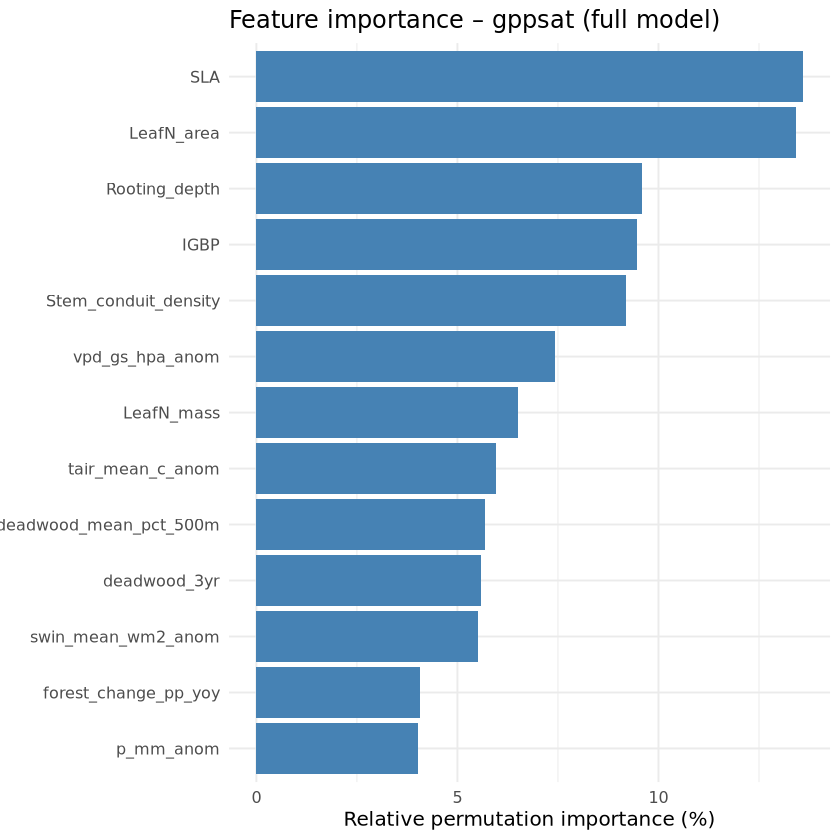

In [27]:
library(data.table)
library(ggplot2)

# Choose target
y <- "gppsat"

# Select model
m <- models[[y]]$full   # or $baseline

library(data.table)
library(ggplot2)

imp_raw <- importance(m)

imp <- data.table(
  feature = names(imp_raw),
  importance = as.numeric(imp_raw)
)

# safety: drop impossible names (should remove nothing, but guarantees no NA)
imp <- imp[!is.na(feature) & feature != ""]

# relative importance (%)
imp[, importance_rel := importance / sum(importance) * 100]
setorder(imp, -importance_rel)

imp_plot <- imp[1:min(15, .N)]
imp_plot <- imp_plot[!is.na(feature)]

ggplot(imp_plot,
       aes(x = reorder(feature, importance_rel), y = importance_rel)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  theme_minimal(base_size = 12) +
  labs(title = paste0("Feature importance – ", y, " (full model)"),
       x = NULL,
       y = "Relative permutation importance (%)")

In [21]:
library(data.table)
library(ggplot2)

# targets must match your models list keys
targets <- c("gppsat","nepmax","etmax","uwue","gsmax")

# output folder
out_dir <- "importance_outputs"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

plot_importance <- function(m, y, model_label, top_k = 15) {
  imp_raw <- importance(m)

  imp <- data.table(
    feature = names(imp_raw),
    importance = as.numeric(imp_raw)
  )

  # drop impossible rows
  imp <- imp[!is.na(feature) & feature != ""]
  imp <- imp[is.finite(importance) & !is.na(importance)]

  # relative importance (%)
  imp[, importance_rel := importance / sum(importance) * 100]
  setorder(imp, -importance_rel)

  top_n <- min(top_k, nrow(imp))
  imp_plot <- imp[1:top_n]

  ggplot(imp_plot,
         aes(x = reorder(feature, importance_rel), y = importance_rel)) +
    geom_col(fill = "steelblue") +
    coord_flip() +
    theme_minimal(base_size = 12) +
    labs(
      title = paste0("Feature importance – ", y, " (", model_label, ")"),
      x = NULL,
      y = "Relative permutation importance (%)"
    )
}

# store plots if you want to print them later
plots <- list()

for (y in targets) {

  if (is.null(models[[y]]$baseline) || is.null(models[[y]]$full)) {
    message("Skipping ", y, " (model missing)")
    next
  }

  p_base <- plot_importance(models[[y]]$baseline, y, "baseline")
  p_full <- plot_importance(models[[y]]$full,     y, "full")

  plots[[y]] <- list(baseline = p_base, full = p_full)

  # save
  ggsave(file.path(out_dir, paste0("importance_", y, "_baseline.png")),
         p_base, width = 7.5, height = 4.8, dpi = 300)

  ggsave(file.path(out_dir, paste0("importance_", y, "_full.png")),
         p_full, width = 7.5, height = 4.8, dpi = 300)
}

message("Saved importance plots to: ", out_dir)

Saved importance plots to: importance_outputs



In [22]:
##colored version
plot_importance <- function(m, y, model_label, top_k = 15) {

  imp_raw <- importance(m)

  imp <- data.table(
    feature = names(imp_raw),
    importance = as.numeric(imp_raw)
  )

  imp <- imp[!is.na(feature) & feature != ""]
  imp <- imp[is.finite(importance) & !is.na(importance)]

  imp[, importance_rel := importance / sum(importance) * 100]
  setorder(imp, -importance_rel)

  # ---- classify feature type ----
  imp[, group := fifelse(
    feature %in% c("p_mm_anom","tair_mean_c_anom",
                   "swin_mean_wm2_anom","vpd_gs_hpa_anom"),
    "Climate",
    fifelse(
      feature %in% c("Rooting_depth","LeafN_mass",
                     "LeafN_area","SLA","Stem_conduit_density"),
      "Plant traits",
      "Mortality / forest"
    )
  )]

  top_n <- min(top_k, nrow(imp))
  imp_plot <- imp[1:top_n]

  ggplot(imp_plot,
         aes(x = reorder(feature, importance_rel),
             y = importance_rel,
             fill = group)) +
    geom_col() +
    coord_flip() +
    scale_fill_manual(values = c(
      "Climate" = "#2C7BB6",           # blue
      "Plant traits" = "#1A9850",      # green
      "Mortality / forest" = "#F28E2B" # orange
    )) +
    theme_minimal(base_size = 12) +
    labs(
      title = paste0("Feature importance – ", y, " (", model_label, ")"),
      x = NULL,
      y = "Relative permutation importance (%)",
      fill = NULL
    )
}

In [23]:
for (y in targets) {

  if (is.null(models[[y]]$baseline) || is.null(models[[y]]$full)) next

  p_base <- plot_importance(models[[y]]$baseline, y, "baseline")
  p_full <- plot_importance(models[[y]]$full,     y, "full")

  ggsave(paste0("importance_", y, "_baseline.png"),
         p_base, width = 8, height = 5, dpi = 300)

  ggsave(paste0("importance_", y, "_full.png"),
         p_full, width = 8, height = 5, dpi = 300)
}

In [8]:
library(data.table)
library(ggplot2)
library(viridisLite)
library(fastshap)

# ---------- Beeswarm function (robust: obs_id + merge; avoids melt guessing)
shap_beeswarm <- function(shap_mat, X, top_n = 12, title = "SHAP summary",
                          xlim_fixed = NULL) {

  sh_mat <- as.matrix(shap_mat)
  X_dt   <- as.data.table(X)

  # Ensure colnames exist and match X
  if (is.null(colnames(sh_mat))) colnames(sh_mat) <- names(X_dt)

  # Keep only common columns (safety)
  common <- intersect(colnames(sh_mat), names(X_dt))
  sh_mat <- sh_mat[, common, drop = FALSE]
  X_dt   <- X_dt[, ..common]

  # Top features by mean |SHAP|
  imp <- sort(colMeans(abs(sh_mat), na.rm = TRUE), decreasing = TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  sh_dt <- as.data.table(sh_mat)
  sh_dt[, obs_id := .I]
  X_dt[,  obs_id := .I]

  sh_long <- melt(sh_dt,
                  id.vars = "obs_id",
                  measure.vars = feats,
                  variable.name = "feature",
                  value.name = "shap")

  x_long  <- melt(X_dt,
                  id.vars = "obs_id",
                  measure.vars = feats,
                  variable.name = "feature",
                  value.name = "value")

  long <- merge(sh_long, x_long, by = c("obs_id", "feature"), all.x = TRUE)

  # order features
  long[, feature := factor(feature, levels = rev(feats))]

  # scale values within each feature (clip 5–95%)
  long[, value_scaled := {
    if (is.numeric(value)) {
      lo <- quantile(value, 0.05, na.rm = TRUE)
      hi <- quantile(value, 0.95, na.rm = TRUE)
      v  <- (value - lo) / (hi - lo)
      pmin(pmax(v, 0), 1)
    } else {
      # fallback for factors/characters if any slip through
      as.numeric(factor(value)) / max(as.numeric(factor(value)), na.rm = TRUE)
    }
  }, by = feature]

  p <- ggplot(long, aes(x = shap, y = feature, color = value_scaled)) +
    geom_vline(xintercept = 0, linewidth = 0.4, color = "grey50") +
    geom_point(position = position_jitter(height = 0.18, width = 0),
               size = 1.2, alpha = 0.85) +
    scale_color_viridis_c(option = "D", name = "Feature value",
                          breaks = c(0, 1), labels = c("Low", "High")) +
    labs(title = title, x = "SHAP value (impact on model output)", y = NULL) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor = element_blank())

  if (!is.null(xlim_fixed)) p <- p + coord_cartesian(xlim = xlim_fixed)
  p
}

In [9]:
shap_heatmap_igbp <- function(shap_mat, igbp_vec, top_n = 12, min_n = 30,
                              title = "Mean |SHAP| by IGBP") {
  library(data.table)
  library(ggplot2)

  sh_mat <- as.matrix(shap_mat)
  if (is.null(colnames(sh_mat))) stop("shap_mat must have column names.")

  global_imp <- sort(colMeans(abs(sh_mat), na.rm = TRUE), decreasing = TRUE)
  feats <- names(global_imp)[1:min(top_n, length(global_imp))]
  feats <- intersect(feats, colnames(sh_mat))

  igbps <- sort(unique(na.omit(igbp_vec)))

  imp_by <- rbindlist(lapply(igbps, function(g) {
    idx <- which(igbp_vec == g)
    if (length(idx) < min_n) return(NULL)
    vals <- colMeans(abs(sh_mat[idx, feats, drop = FALSE]), na.rm = TRUE)
    data.table(IGBP = g, feature = names(vals), mean_abs_shap = as.numeric(vals), n = length(idx))
  }), fill = TRUE)

  if (nrow(imp_by) == 0) {
    return(ggplot() + theme_void() +
             labs(title = title, subtitle = paste0("No IGBP group had n ≥ ", min_n)))
  }

  imp_by[, feature := factor(feature, levels = feats)]

  ggplot(imp_by, aes(x = feature, y = IGBP, fill = mean_abs_shap)) +
    geom_tile() +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = title,
         subtitle = paste0("Groups with n ≥ ", min_n, " shown"),
         x = NULL, y = NULL)
}


In [10]:
y <- "GPPsat"
m <- models[[y]]$full

# IMPORTANT: SHAP must use the SAME predictors the model was trained with (includes IGBP!)
train_full <- train_df[
  !is.na(get(y)) &
    !is.na(deadwood_mean_500m) &
    !is.na(forest_mean_500m) &
    !is.na(deadwood_3yr) &
    !is.na(IGBP)
]

X_shap <- train_full[, pred_full, with = FALSE]   # includes IGBP
stopifnot(nrow(X_shap) == nrow(train_full))

# Compute SHAP
sh <- explain(
  object = m,
  X = X_shap,
  pred_wrapper = function(object, newdata)
    predict(object, data = newdata)$predictions,
  nsim = 100
)

# Ensure alignment
stopifnot(nrow(X_shap) == nrow(sh))

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.

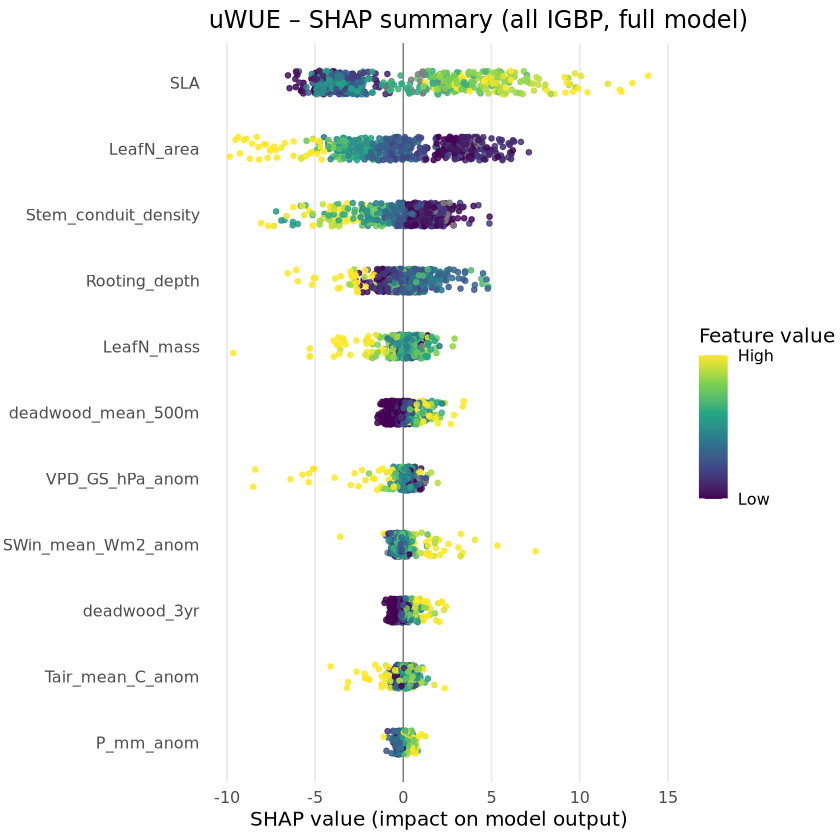

In [11]:
sh_plot <- sh
if (!is.null(colnames(sh_plot)) && "IGBP" %in% colnames(sh_plot)) {
  sh_plot <- sh_plot[, setdiff(colnames(sh_plot), "IGBP"), drop = FALSE]
}

X_plot <- X_shap
if ("IGBP" %in% names(X_plot)) {
  X_plot <- X_plot[, setdiff(names(X_plot), "IGBP"), with = FALSE]
}

# Shared x-limits for consistent comparison
xlim_fixed <- range(as.matrix(sh_plot), na.rm = TRUE)

# --- Global beeswarm
p_all <- shap_beeswarm(
  shap_mat = sh_plot,
  X = X_plot,
  top_n = 12,
  title = "uWUE – SHAP summary (all IGBP, full model)",
  xlim_fixed = xlim_fixed
)
p_all


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (IGBP=CRO, n=51)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (IGBP=CRO, n=51)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (IGBP=CRO, n=51)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (IGBP=CRO, n=51)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (IGBP=CRO, n=51)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call.graphics(C_text, as.graphicsAn

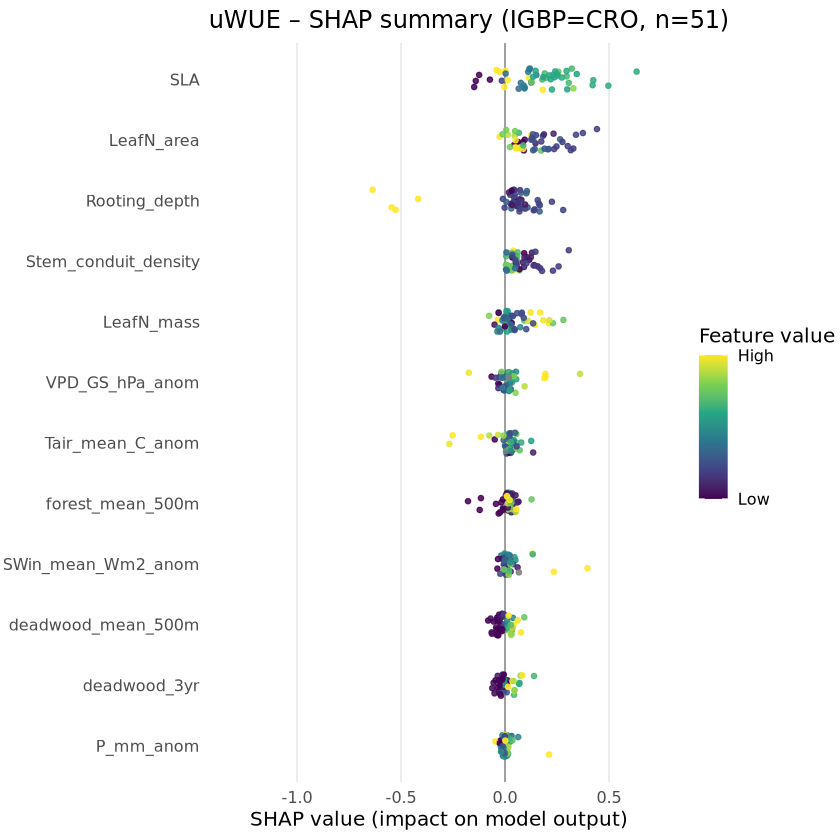

In [21]:
# --- Beeswarm per IGBP
min_n <- 30
igbps <- sort(unique(na.omit(train_full$IGBP)))

plots_igbp <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < min_n) next

  plots_igbp[[g]] <- shap_beeswarm(
    shap_mat = sh_plot[idx, , drop = FALSE],
    X        = X_plot[idx, , drop = FALSE],
    top_n    = 12,
    title    = paste0("uWUE – SHAP summary (IGBP=", g, ", n=", length(idx), ")"),
    xlim_fixed = xlim_fixed
  )
}
# Show one example safely
if (length(plots_igbp) > 0) {
  plots_igbp[[1]]
} else {
  message("No IGBP group had n >= min_n (try min_n <- 20).")
}


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, 

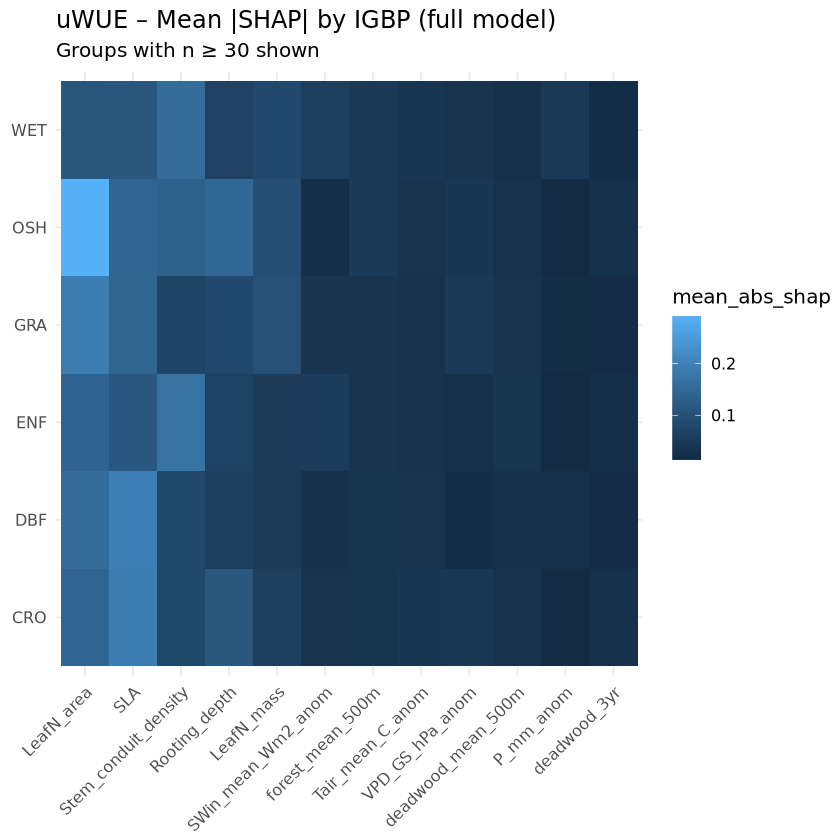

In [22]:
# --- Heatmap mean |SHAP| by IGBP (use sh_plot: IGBP removed as a feature)
p_hm <- shap_heatmap_igbp(
  shap_mat = sh_plot,
  igbp_vec = train_full$IGBP,
  top_n = 12,
  min_n = 30,
  title = "uWUE – Mean |SHAP| by IGBP (full model)"
)
p_hm


In [23]:
# Save outputs
# ----------------------------
dir.create("shap_outputs_uWUE", showWarnings = FALSE, recursive = TRUE)
dir.create("shap_outputs_uWUE/beeswarm_by_igbp", showWarnings = FALSE, recursive = TRUE)

ggsave("shap_outputs_uWUE/beeswarm_all.png", p_all, width = 8, height = 5, dpi = 300)
ggsave("shap_outputs_uWUE/heatmap_igbp.png", p_hm, width = 9, height = 5, dpi = 300)

for (g in names(plots_igbp)) {
  ggsave(
    filename = file.path("shap_outputs_uWUE/beeswarm_by_igbp",
                         paste0("beeswarm_IGBP_", g, ".png")),
    plot = plots_igbp[[g]],
    width = 8, height = 5, dpi = 300
  )
}

In [11]:
library(fastshap)
y <- "NEPmax"
m <- models[[y]]$full


X_shap <- train_full[, pred_full, with = FALSE]   # includes IGBP!
sh <- explain(
  object = m,
  X = X_shap,
  pred_wrapper = function(object, newdata)
    predict(object, data = newdata)$predictions,
  nsim = 100

)

ERROR: Error: object 'train_full' not found


Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – SHAP summary (al

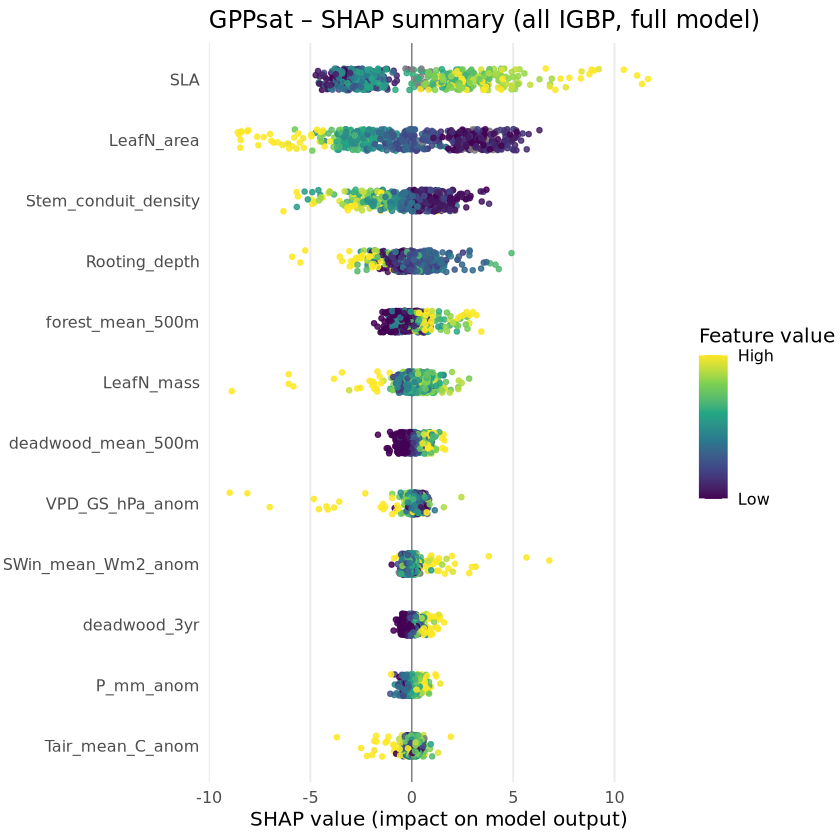

In [50]:
# Ensure alignment
stopifnot(nrow(X) == nrow(sh))
stopifnot(nrow(train_full) == nrow(X))

# Shared x-limits (important for comparing IGBP plots)
xlim_fixed <- range(as.matrix(sh), na.rm = TRUE)

# --- General beeswarm
p_all <- shap_beeswarm(sh, X, top_n = 12,
                       title = "GPPsat – SHAP summary (all IGBP, full model)",
                       xlim_fixed = xlim_fixed,
                       drop_features = "IGBP")
p_all

In [51]:
min_n <- 30
igbps <- sort(unique(na.omit(train_full$IGBP)))

plots_igbp <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < min_n) next

  plots_igbp[[g]] <- shap_beeswarm(
    shap_mat = sh[idx, , drop=FALSE],
    X = X[idx, , drop=FALSE],
    top_n = 12,
    title = paste0("GPPsat – SHAP summary (IGBP=", g, ", n=", length(idx), ")"),
    xlim_fixed = xlim_fixed
  )
}

# Show one example:
plots_igbp[[1]]

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


ERROR: Error in `[.data.table`(X_dt, , ..feats): column not found: [IGBP]


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GPPsat – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x,

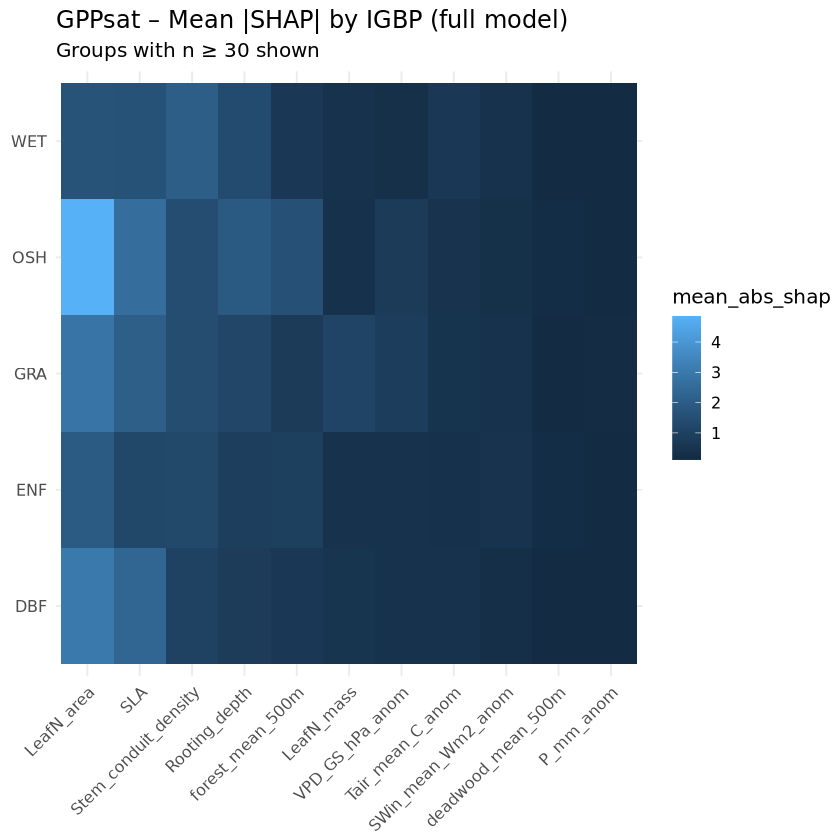

In [70]:
p_hm <- shap_heatmap_igbp(
  shap_mat = sh,
  igbp_vec = train_full$IGBP,
  top_n = 12,
  min_n = 30,
  title = "GPPsat – Mean |SHAP| by IGBP (full model)"
)
p_hm

In [56]:
dir.create("shap_outputs_GPPsat", showWarnings = FALSE)

ggsave("shap_outputs_GPPsat/beeswarm_all.png", p_all, width=8, height=5, dpi=300)
ggsave("shap_outputs_GPPsat/heatmap_igbp.png", p_hm, width=9, height=5, dpi=300)

dir.create("shap_outputs_GPPsat/beeswarm_by_igbp", showWarnings = FALSE)

for (g in names(plots_igbp)) {
  ggsave(
    filename = file.path("shap_outputs_GPPsat/beeswarm_by_igbp", paste0("beeswarm_IGBP_", g, ".png")),
    plot = plots_igbp[[g]],
    width = 8, height = 5, dpi = 300
  )
}

NEPmax

In [2]:
library(fastshap)

y <- "NEPmax"
m <- models[[y]]$full

train_full <- train_df[!is.na(get(y)) & !is.na(deadwood_mean_500m) & !is.na(forest_mean_500m)]
X <- train_full[, pred_full, with = FALSE]

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

ERROR: Error: object 'models' not found


In [51]:
library(data.table)
library(ggplot2)
library(viridisLite)

shap_beeswarm <- function(shap_mat, X, top_n = 12, title = "SHAP summary",
                          xlim_fixed = NULL) {
  sh_dt <- as.data.table(as.matrix(shap_mat))
  X_dt  <- as.data.table(X)

  # importance within the provided subset
  imp <- sort(colMeans(abs(as.matrix(sh_dt)), na.rm = TRUE), decreasing = TRUE)
  feats <- names(imp)[1:min(top_n, length(imp))]

  sh_long <- melt(sh_dt[, ..feats], variable.name="feature", value.name="shap")
  x_long  <- melt(X_dt[,  ..feats], variable.name="feature", value.name="value")
  sh_long[, value := x_long$value]

  # order features by importance top->bottom
  sh_long[, feature := factor(feature, levels = rev(feats))]

  # scale values within each feature (clip 5–95%)
  sh_long[, value_scaled := {
    lo <- quantile(value, 0.05, na.rm = TRUE)
    hi <- quantile(value, 0.95, na.rm = TRUE)
    v  <- (value - lo) / (hi - lo)
    pmin(pmax(v, 0), 1)
  }, by = feature]

  p <- ggplot(sh_long, aes(x = shap, y = feature, color = value_scaled)) +
    geom_vline(xintercept = 0, linewidth = 0.4, color = "grey50") +
    geom_point(position = position_jitter(height = 0.18, width = 0),
               size = 1.2, alpha = 0.85) +
    scale_color_viridis_c(option = "D", name = "Feature value",
                          breaks = c(0, 1), labels = c("Low", "High")) +
    labs(title = title, x = "SHAP value (impact on model output)", y = NULL) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor = element_blank())

  if (!is.null(xlim_fixed)) p <- p + coord_cartesian(xlim = xlim_fixed)
  p
}

In [50]:
shap_heatmap_igbp <- function(shap_mat, igbp_vec, top_n = 12, min_n = 30,
                              title = "Mean |SHAP| by IGBP") {
  sh_mat <- as.matrix(shap_mat)

  # global top features
  global_imp <- sort(colMeans(abs(sh_mat), na.rm=TRUE), decreasing=TRUE)
  feats <- names(global_imp)[1:min(top_n, length(global_imp))]
  feats <- intersect(feats, colnames(sh_mat))

  igbps <- sort(unique(na.omit(igbp_vec)))

  imp_by <- rbindlist(lapply(igbps, function(g) {
    idx <- which(igbp_vec == g)
    if (length(idx) < min_n) return(NULL)
    vals <- colMeans(abs(sh_mat[idx, feats, drop=FALSE]), na.rm=TRUE)
    data.table(IGBP = g, feature = names(vals), mean_abs_shap = as.numeric(vals), n = length(idx))
  }), fill=TRUE)

  # order features (global)
  imp_by[, feature := factor(feature, levels = feats)]

  ggplot(imp_by, aes(x = feature, y = IGBP, fill = mean_abs_shap)) +
    geom_tile() +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = title, subtitle = paste0("Groups with n ≥ ", min_n, " shown"),
         x = NULL, y = NULL)
}

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NEPmax – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NEPmax – SHAP summary (al

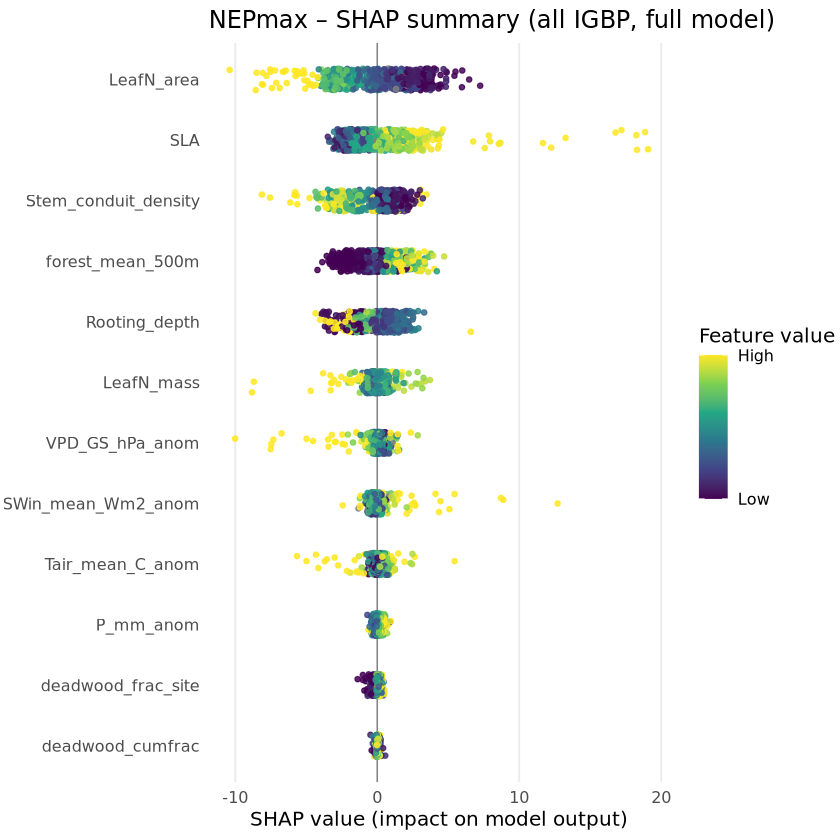

In [30]:
# Ensure alignment
stopifnot(nrow(X) == nrow(sh))
stopifnot(nrow(train_full) == nrow(X))

# Shared x-limits (important for comparing IGBP plots)
xlim_fixed <- range(as.matrix(sh), na.rm = TRUE)

# --- General beeswarm
p_all <- shap_beeswarm(sh, X, top_n = 12,
                       title = "NEPmax – SHAP summary (all IGBP, full model)",
                       xlim_fixed = xlim_fixed)
p_all

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”

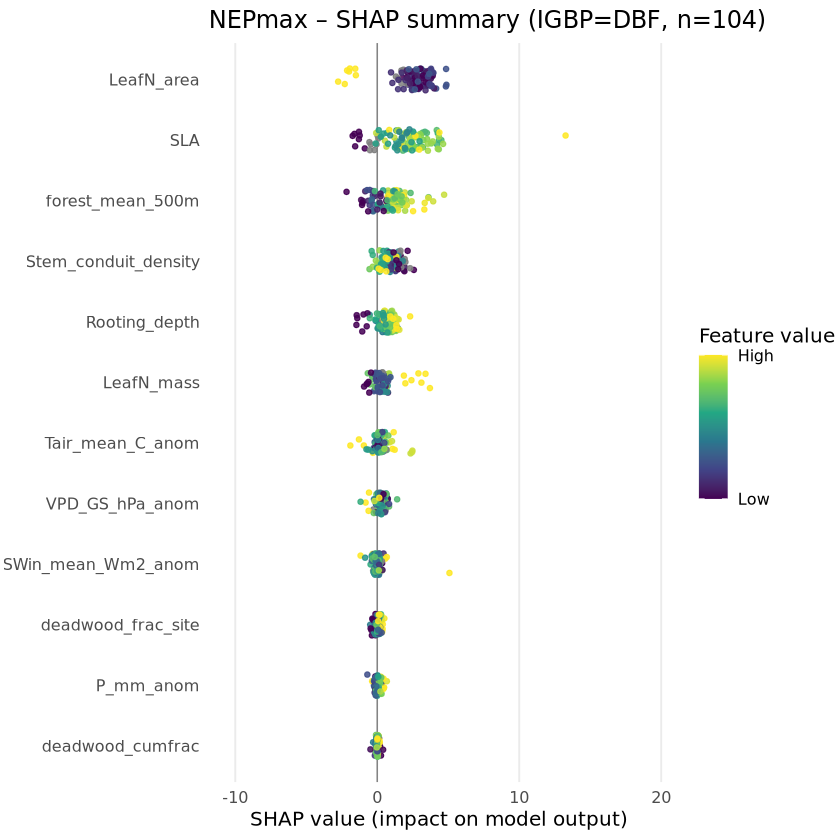

In [31]:
min_n <- 30
igbps <- sort(unique(na.omit(train_full$IGBP)))

plots_igbp <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < min_n) next

  plots_igbp[[g]] <- shap_beeswarm(
    shap_mat = sh[idx, , drop=FALSE],
    X = X[idx, , drop=FALSE],
    top_n = 12,
    title = paste0("NEPmax – SHAP summary (IGBP=", g, ", n=", length(idx), ")"),
    xlim_fixed = xlim_fixed
  )
}

# Show one example:
plots_igbp[[1]]

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NEPmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NEPmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'NEPmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x,

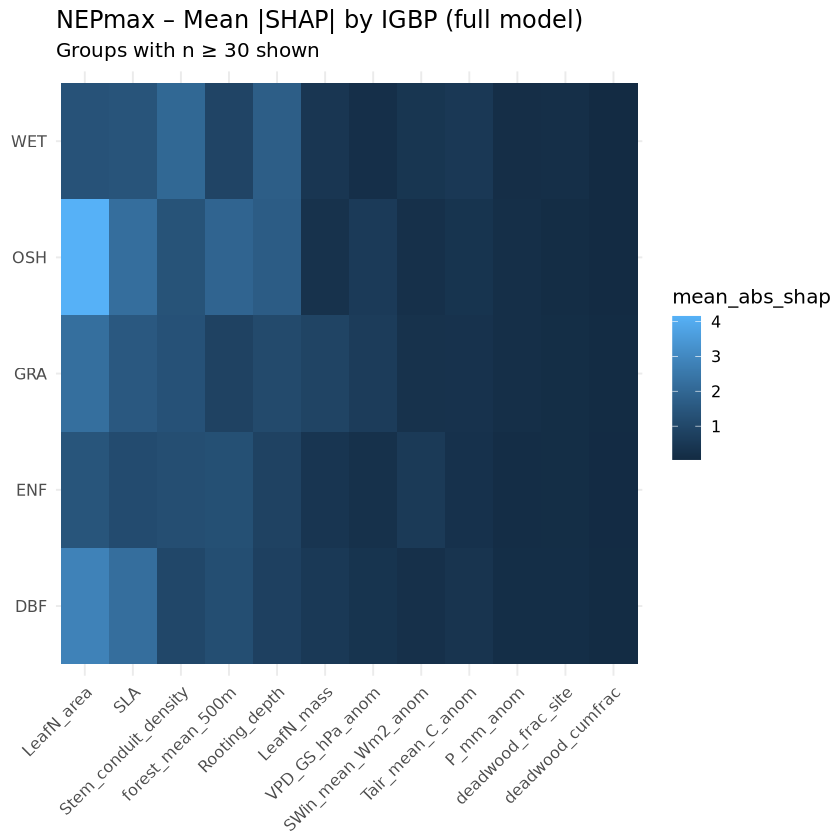

In [32]:
p_hm <- shap_heatmap_igbp(
  shap_mat = sh,
  igbp_vec = train_full$IGBP,
  top_n = 12,
  min_n = 30,
  title = "NEPmax – Mean |SHAP| by IGBP (full model)"
)
p_hm

In [33]:
dir.create("shap_outputs_NEPmax", showWarnings = FALSE)

ggsave("shap_outputs_NEPmax/beeswarm_all.png", p_all, width=8, height=5, dpi=300)
ggsave("shap_outputs_NEPmax/heatmap_igbp.png", p_hm, width=9, height=5, dpi=300)

dir.create("shap_outputs_NEPmax/beeswarm_by_igbp", showWarnings = FALSE)

for (g in names(plots_igbp)) {
  ggsave(
    filename = file.path("shap_outputs_NEPmax/beeswarm_by_igbp", paste0("beeswarm_IGBP_", g, ".png")),
    plot = plots_igbp[[g]],
    width = 8, height = 5, dpi = 300
  )
}

ETmax

In [34]:
library(fastshap)

y <- "ETmax"
m <- models[[y]]$full

train_full <- train_df[!is.na(get(y)) & !is.na(deadwood_frac_site) & !is.na(forest_mean_500m)]
X <- train_full[, pred_full, with = FALSE]

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ETmax – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ETmax – SHAP summary (all 

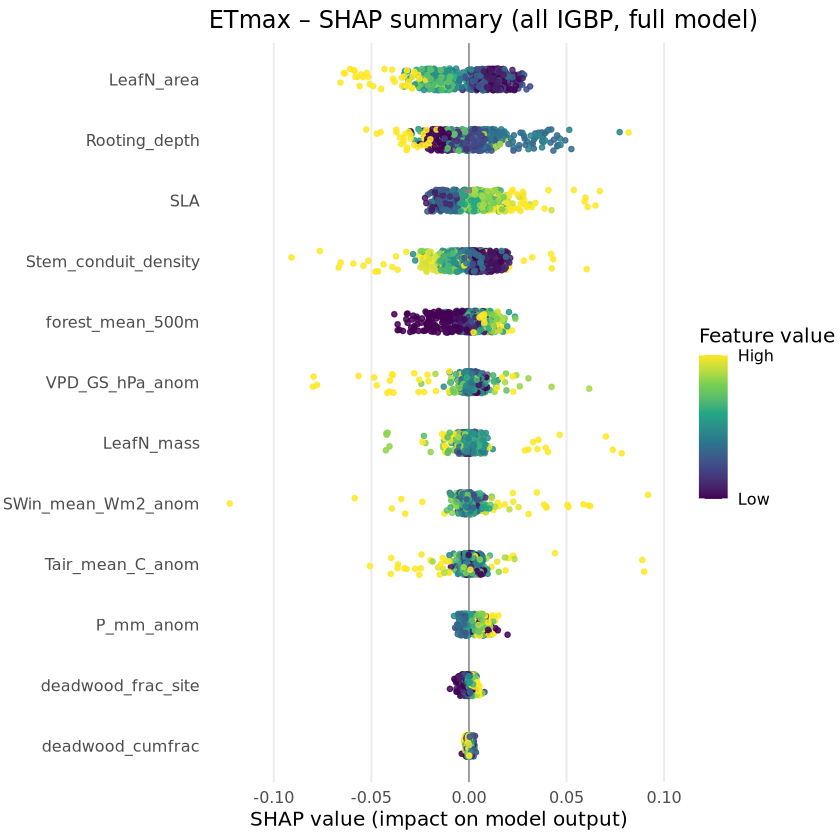

In [35]:
stopifnot(nrow(X) == nrow(sh))
stopifnot(nrow(train_full) == nrow(X))

# Shared x-limits (important for comparing IGBP plots)
xlim_fixed <- range(as.matrix(sh), na.rm = TRUE)

# --- General beeswarm
p_all <- shap_beeswarm(sh, X, top_n = 12,
                       title = "ETmax – SHAP summary (all IGBP, full model)",
                       xlim_fixed = xlim_fixed)
p_all

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”

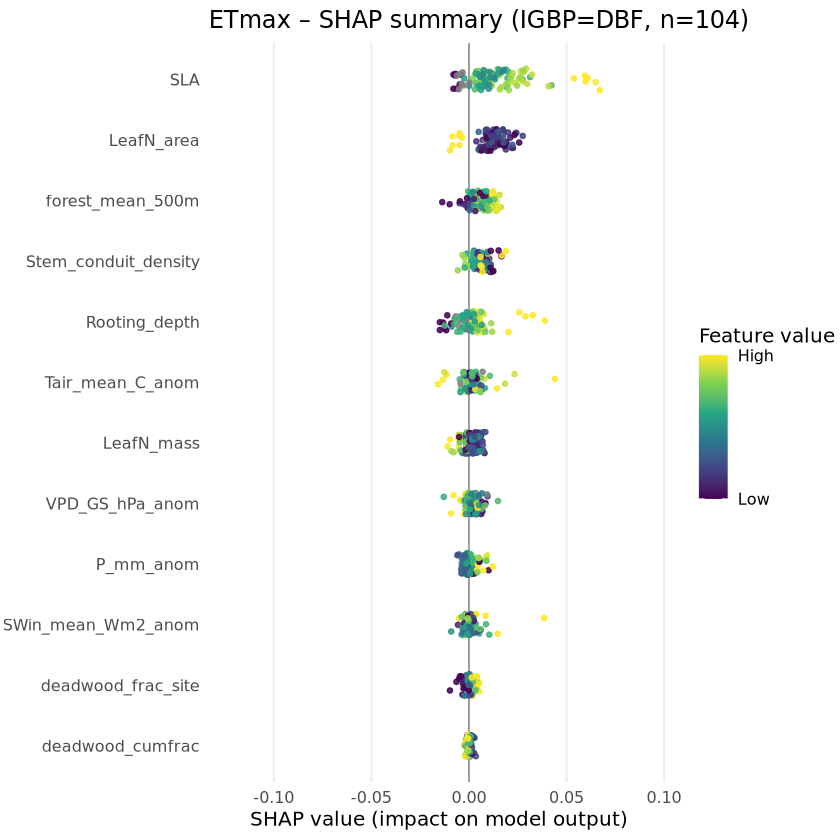

In [36]:
min_n <- 30
igbps <- sort(unique(na.omit(train_full$IGBP)))

plots_igbp <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < min_n) next

  plots_igbp[[g]] <- shap_beeswarm(
    shap_mat = sh[idx, , drop=FALSE],
    X = X[idx, , drop=FALSE],
    top_n = 12,
    title = paste0("ETmax – SHAP summary (IGBP=", g, ", n=", length(idx), ")"),
    xlim_fixed = xlim_fixed
  )
}

# Show one example:
plots_igbp[[1]]

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ETmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ETmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ETmax – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$

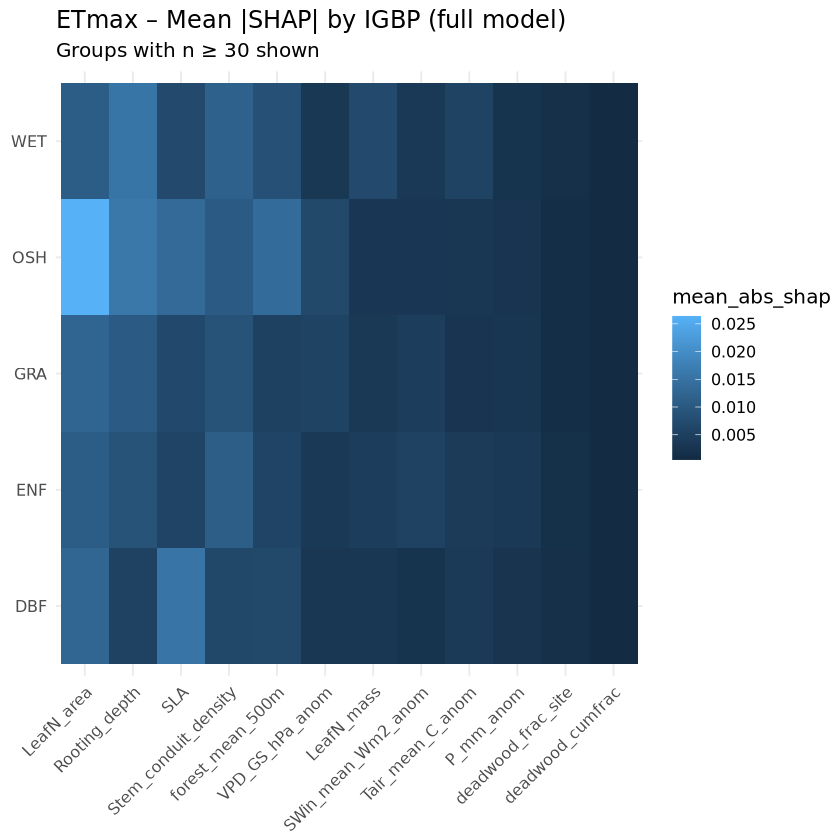

In [37]:
p_hm <- shap_heatmap_igbp(
  shap_mat = sh,
  igbp_vec = train_full$IGBP,
  top_n = 12,
  min_n = 30,
  title = "ETmax – Mean |SHAP| by IGBP (full model)"
)
p_hm

In [38]:
dir.create("shap_outputs_ETmax", showWarnings = FALSE)

ggsave("shap_outputs_ETmax/beeswarm_all.png", p_all, width=8, height=5, dpi=300)
ggsave("shap_outputs_ETmax/heatmap_igbp.png", p_hm, width=9, height=5, dpi=300)

dir.create("shap_outputs_ETmax/beeswarm_by_igbp", showWarnings = FALSE)

for (g in names(plots_igbp)) {
  ggsave(
    filename = file.path("shap_outputs_ETmax/beeswarm_by_igbp", paste0("beeswarm_IGBP_", g, ".png")),
    plot = plots_igbp[[g]],
    width = 8, height = 5, dpi = 300
  )
}

uWUE

In [39]:
library(fastshap)

y <- "uWUE"
m <- models[[y]]$full

train_full <- train_df[!is.na(get(y)) & !is.na(deadwood_frac_site) & !is.na(forest_mean_500m)]
X <- train_full[, pred_full, with = FALSE]

sh <- explain(
  object = m,
  X = X,
  pred_wrapper = function(object, newdata) predict(object, data = newdata)$predictions,
  nsim = 100
)

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IGBP, full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – SHAP summary (all IG

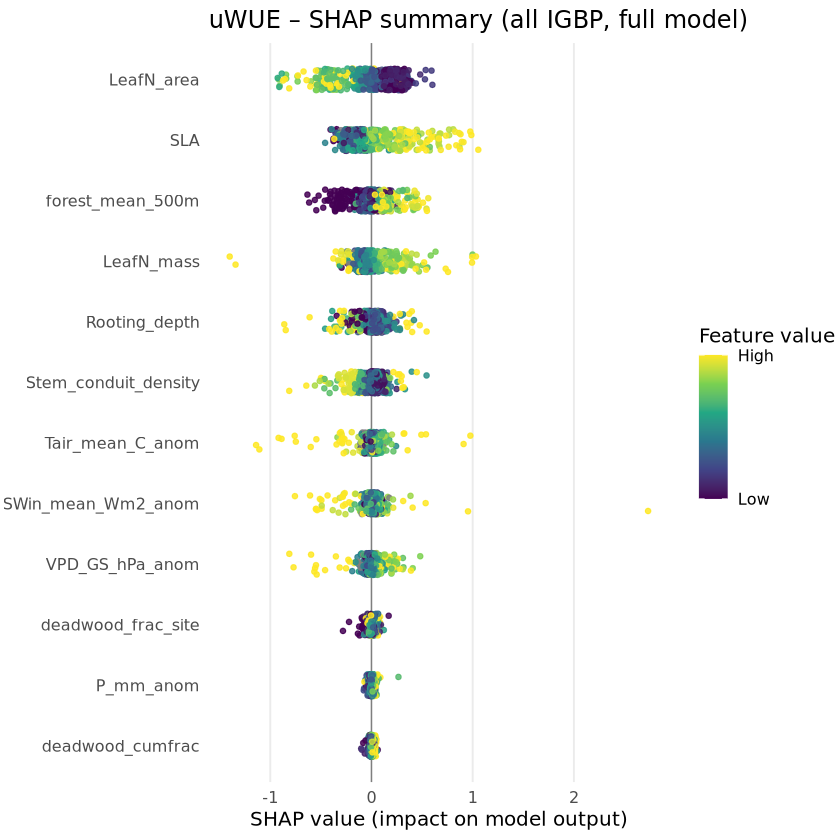

In [40]:
stopifnot(nrow(X) == nrow(sh))
stopifnot(nrow(train_full) == nrow(X))

# Shared x-limits (important for comparing IGBP plots)
xlim_fixed <- range(as.matrix(sh), na.rm = TRUE)

# --- General beeswarm
p_all <- shap_beeswarm(sh, X, top_n = 12,
                       title = "uWUE – SHAP summary (all IGBP, full model)",
                       xlim_fixed = xlim_fixed)
p_all

Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(X_dt[, ..feats], variable.name = "feature", value.name = "value"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”
Warning message in melt.data.table(sh_dt[, ..feats], variable.name = "feature", :
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”

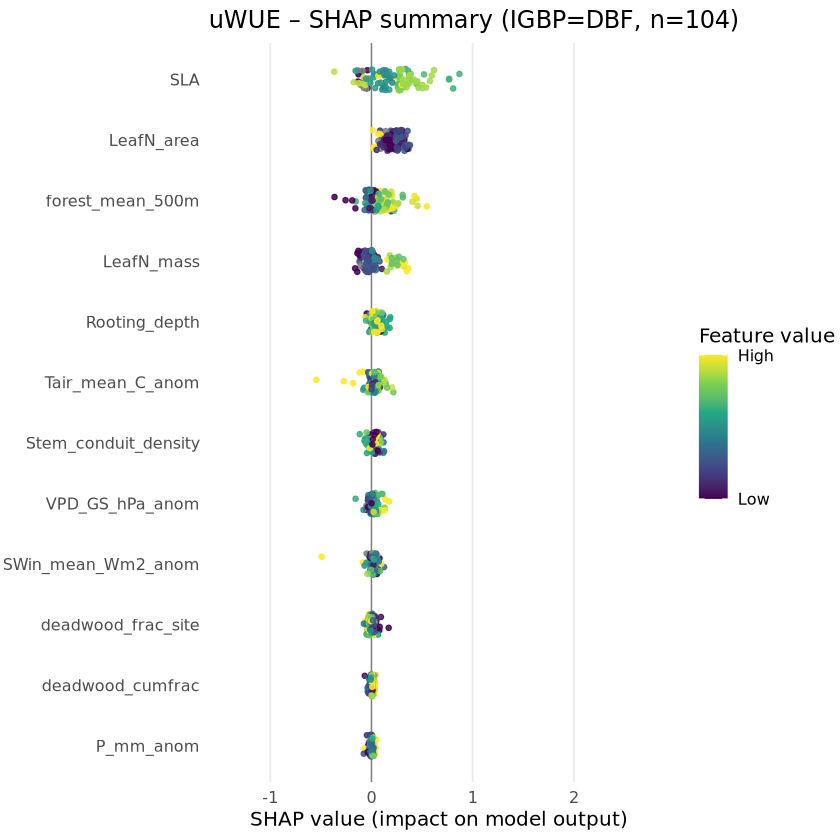

In [41]:
min_n <- 30
igbps <- sort(unique(na.omit(train_full$IGBP)))

plots_igbp <- list()

for (g in igbps) {
  idx <- which(train_full$IGBP == g)
  if (length(idx) < min_n) next

  plots_igbp[[g]] <- shap_beeswarm(
    shap_mat = sh[idx, , drop=FALSE],
    X = X[idx, , drop=FALSE],
    top_n = 12,
    title = paste0("uWUE – SHAP summary (IGBP=", g, ", n=", length(idx), ")"),
    xlim_fixed = xlim_fixed
  )
}

# Show one example:
plots_igbp[[1]]

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'uWUE – Mean |SHAP| by IGBP (full model)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Groups with n ≥ 30 shown' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, 

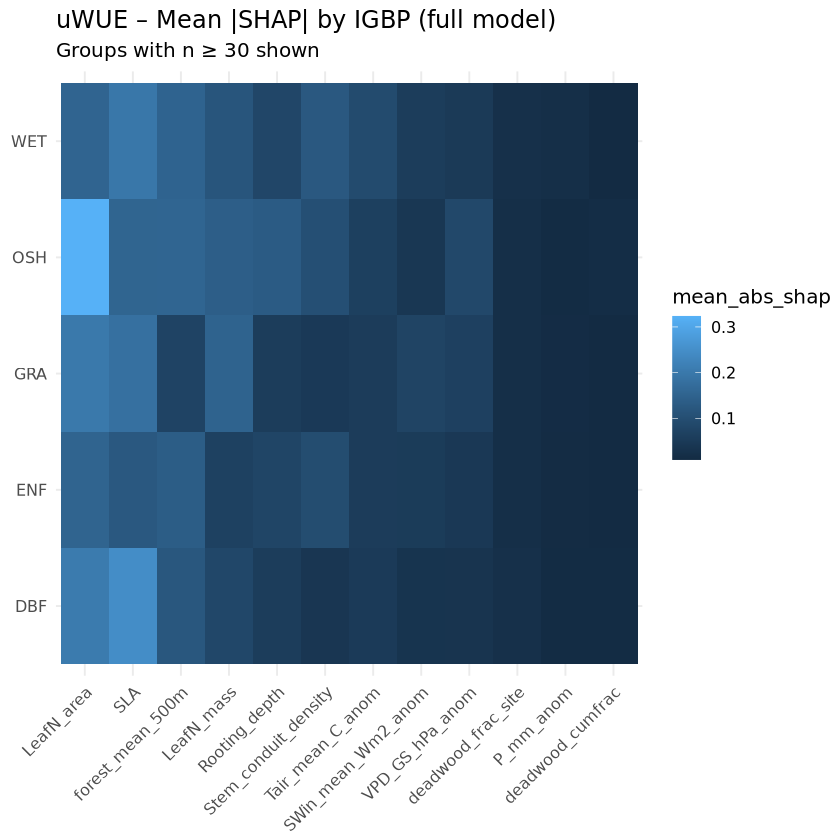

In [42]:
p_hm <- shap_heatmap_igbp(
  shap_mat = sh,
  igbp_vec = train_full$IGBP,
  top_n = 12,
  min_n = 30,
  title = "uWUE – Mean |SHAP| by IGBP (full model)"
)
p_hm

In [43]:
dir.create("shap_outputs_uWUE", showWarnings = FALSE)

ggsave("shap_outputs_uWUE/beeswarm_all.png", p_all, width=8, height=5, dpi=300)
ggsave("shap_outputs_uWUE/heatmap_igbp.png", p_hm, width=9, height=5, dpi=300)

dir.create("shap_outputs_uWUE/beeswarm_by_igbp", showWarnings = FALSE)

for (g in names(plots_igbp)) {
  ggsave(
    filename = file.path("shap_outputs_uWUE/beeswarm_by_igbp", paste0("beeswarm_IGBP_", g, ".png")),
    plot = plots_igbp[[g]],
    width = 8, height = 5, dpi = 300
  )
}